In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

Repo already exists — pulling latest changes
Already up to date.


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

In [3]:
import importlib
import scipy.sparse as sps
import pandas as pd
import numpy as np

from Challenge import paths
importlib.reload(paths)

from Challenge.hyper_tuning import hyperparameter_tuning

Running on local — storage at: /home/luigi/RecSys
Running on local — storage at: /home/luigi/RecSys


In [4]:
# Load datasets
URM_train = sps.load_npz(paths.URM_TRAIN)
URM_validation = sps.load_npz(paths.URM_VALIDATION)

## **Explore URM to segment them in differnt categories**

# ideas:
- Sparsity (number of interaction)
- Similarity (some similarity)
- Percentage of interactions with rare items

Instead of segmenting with some heuristic we can separate the user based on which model perform better on them

In [5]:
def evaluate_recommender(recommender, at):
    cumulative_recall = 0.0
    num_eval = 0
    
    for user_id in range(URM_validation.shape[0]):
        relevant_items = URM_validation.indices[URM_validation.indptr[user_id]:URM_validation.indptr[user_id+1]]
        
        if len(relevant_items)>0:
            num_eval+=1
            
            recommended_items = recommender.recommend(user_id, cutoff=at)
            
            is_relevant = np.isin(recommended_items, relevant_items, assume_unique=True)
            recall_score = np.sum(is_relevant, dtype=np.float32) / relevant_items.shape[0]

            cumulative_recall += recall_score

    return cumulative_recall / num_eval

# **Load Models**

In [6]:
models = {}

### **SLIM**

In [7]:
from Recommenders.SLIM.SLIMElasticNetRecommender import SLIMElasticNetRecommender

# Train SLIM model with best parameters
# {"l1_ratio": 0.6257826858334088, "alpha": 0.000818987106299432, "topK": 646, "positive_only": false}
slim_model = SLIMElasticNetRecommender(URM_train)
slim_model.fit(
    l1_ratio=0.6257826858334088,
    alpha=0.000818987106299432,
    topK=646,
    positive_only=False
)

# Add SLIM model to models dictionary
models['SLIM'] = slim_model

# Evaluate SLIM model
slim_recall = evaluate_recommender(slim_model, at=20)
print(f"SLIM Model - Recall@20: {slim_recall:.5f}")

SLIMElasticNetRecommender: Processed 6969 (100.0%) in 3.51 min. Items per second: 33.10
SLIM Model - Recall@20: 0.29005


### **EASE_R**

In [8]:
from Recommenders.EASE_R.EASE_R_Recommender import EASE_R_Recommender

# Train EASE_R model with best parameters
# {"topK": 850, "l2": 400.12671834453766, "normalize": false}
ease_r_model = EASE_R_Recommender(URM_train)
ease_r_model.fit(
    topK=850,
    l2_norm=400.12671834453766,
    normalize_matrix=False
)

# Add EASE_R model to models dictionary
models['EASE_R'] = ease_r_model

# Evaluate EASE_R model
ease_r_recall = evaluate_recommender(ease_r_model, at=20)
print(f"EASE_R Model - Recall@20: {ease_r_recall:.5f}")

EASE_R_Recommender: Fitting model... 
EASE_R_Recommender: Fitting model... done in 6.97 sec
EASE_R Model - Recall@20: 0.28327


### **TopPop**

In [9]:
from Recommenders.NonPersonalizedRecommender import TopPop

# Train TopPop model
toppop_model = TopPop(URM_train)
toppop_model.fit()

# Add TopPop model to models dictionary
models['TopPop'] = toppop_model

# Evaluate TopPop model
toppop_recall = evaluate_recommender(toppop_model, at=20)
print(f"TopPop Model - Recall@20: {toppop_recall:.5f}")

TopPop Model - Recall@20: 0.10760


### **KNN**

In [10]:
SIMILIARITIES = ["cosine", "pearson", "jaccard", "tversky"]

#### **UserKNN**

In [11]:
from Recommenders.KNN.UserKNNCFRecommender import UserKNNCFRecommender

params = {
    "cosine": {"topK": 347, "shrink": 3, "normalize": True, "feature_weighting": "TF-IDF"},
    "pearson": {"topK": 2850, "shrink": 935, "normalize": True, "feature_weighting": "TF-IDF"},
    "jaccard": {"topK": 301, "shrink": 0, "normalize": True, "feature_weighting": "none"},
    "tversky": {"topK": 401, "shrink": 5, "normalize": False, "feature_weighting": "TF-IDF", "alpha": 0.2184775930703794, "beta": 0.5934354684918872}
}

for sim in SIMILIARITIES:
    # Train UserKNN model with best parameters
    userknn_model = UserKNNCFRecommender(URM_train)

    if sim == "tversky":
        userknn_model.fit(
            similarity=sim,
            topK=params[sim]["topK"],
            shrink=params[sim]["shrink"],
            normalize=params[sim]["normalize"],
            feature_weighting=params[sim]["feature_weighting"],
            tversky_alpha=params[sim]["alpha"],
            tversky_beta=params[sim]["beta"]
        )
    else:
        userknn_model.fit(
            similarity=sim,
            topK=params[sim]["topK"],
            shrink=params[sim]["shrink"],
            normalize=params[sim]["normalize"],
            feature_weighting=params[sim]["feature_weighting"]
        )

    # Add UserKNN model to models dictionary
    models['UserKNN'+sim] = userknn_model

    # Evaluate UserKNN model
    userknn_recall = evaluate_recommender(userknn_model, at=20)
    print(f"UserKNN {sim} Model - Recall@20: {userknn_recall:.5f}")

Similarity column 27095 (100.0%), 1773.82 column/sec. Elapsed time 15.27 sec
UserKNN cosine Model - Recall@20: 0.22337
Similarity column 27095 (100.0%), 1835.65 column/sec. Elapsed time 14.76 sec
UserKNN pearson Model - Recall@20: 0.11340
Similarity column 27095 (100.0%), 1824.74 column/sec. Elapsed time 14.85 sec
UserKNN jaccard Model - Recall@20: 0.22148
Similarity column 27095 (100.0%), 1789.37 column/sec. Elapsed time 15.14 sec
UserKNN tversky Model - Recall@20: 0.22302


#### **ItemKNN**

In [12]:
from Recommenders.KNN.ItemKNNCFRecommender import ItemKNNCFRecommender

params = {
    "cosine": {"topK": 79, "shrink": 431, "normalize": True, "feature_weighting": "TF-IDF"},
    "pearson": {"topK": 11, "shrink": 3, "normalize": True, "feature_weighting": "TF-IDF"},
    "jaccard": {"topK": 1101, "shrink": 0, "normalize": True, "feature_weighting": "BM25"},
    "tversky": {"topK": 6, "shrink": 106, "normalize": True, "feature_weighting": "TF-IDF", "tversky_alpha": 0.10252983277640502, "tversky_beta": 0.9684276681445425}
}

for sim in SIMILIARITIES:
    # Train ItemKNN model with best parameters
    itemknn_model = ItemKNNCFRecommender(URM_train)
    
    if sim == "tversky":
        itemknn_model.fit(
            similarity=sim,
            topK=params[sim]["topK"],
            shrink=params[sim]["shrink"],
            normalize=params[sim]["normalize"],
            feature_weighting=params[sim]["feature_weighting"],
            tversky_alpha=params[sim]["tversky_alpha"],
            tversky_beta=params[sim]["tversky_beta"]
        )
    else:
        itemknn_model.fit(
            similarity=sim,
            topK=params[sim]["topK"],
            shrink=params[sim]["shrink"],
            normalize=params[sim]["normalize"],
            feature_weighting=params[sim]["feature_weighting"]
        )

    # Add ItemKNN model to models dictionary
    models['ItemKNN'+sim] = itemknn_model

    # Evaluate ItemKNN model
    itemknn_recall = evaluate_recommender(itemknn_model, at=20)
    print(f"ItemKNN {sim} Model - Recall@20: {itemknn_recall:.5f}")

Similarity column 6969 (100.0%), 4702.77 column/sec. Elapsed time 1.48 sec
ItemKNN cosine Model - Recall@20: 0.21803
Similarity column 6969 (100.0%), 4684.47 column/sec. Elapsed time 1.49 sec
ItemKNN pearson Model - Recall@20: 0.21078
Similarity column 6969 (100.0%), 4631.20 column/sec. Elapsed time 1.50 sec
ItemKNN jaccard Model - Recall@20: 0.19176
Similarity column 6969 (100.0%), 4713.37 column/sec. Elapsed time 1.48 sec
ItemKNN tversky Model - Recall@20: 0.25053


## **Evaluate performance of each model per user**

In [13]:
df_models_performance = pd.DataFrame(index=np.arange(URM_train.shape[0]), columns=models.keys())

# Populate performance DataFrame
for user_id in range(URM_validation.shape[0]):
    if user_id % 1000 == 0:
        print(f"Evaluating user {user_id}/{URM_validation.shape[0]}")

    relevant_items = URM_validation.indices[URM_validation.indptr[user_id]:URM_validation.indptr[user_id+1]]
    
    if len(relevant_items)>0:
        for model_name, model in models.items():
            recommended_items = model.recommend(user_id, cutoff=20)
            
            is_relevant = np.isin(recommended_items, relevant_items, assume_unique=True)
            recall_score = np.sum(is_relevant, dtype=np.float32) / relevant_items.shape[0]

            # Store recall score in DataFrame
            df_models_performance.at[user_id, model_name] = recall_score

# Save performance DataFrame to CSV
df_models_performance.to_csv("model_performance_per_user.csv", index_label="user_id")

Evaluating user 0/27095
Evaluating user 1000/27095
Evaluating user 2000/27095
Evaluating user 3000/27095
Evaluating user 4000/27095
Evaluating user 5000/27095
Evaluating user 6000/27095
Evaluating user 7000/27095
Evaluating user 8000/27095
Evaluating user 9000/27095
Evaluating user 10000/27095
Evaluating user 11000/27095
Evaluating user 12000/27095
Evaluating user 13000/27095
Evaluating user 14000/27095
Evaluating user 15000/27095
Evaluating user 16000/27095
Evaluating user 17000/27095
Evaluating user 18000/27095
Evaluating user 19000/27095
Evaluating user 20000/27095
Evaluating user 21000/27095
Evaluating user 22000/27095
Evaluating user 23000/27095
Evaluating user 24000/27095
Evaluating user 25000/27095
Evaluating user 26000/27095
Evaluating user 27000/27095


In [14]:
# Print recall for each model to verify
for model_name in models.keys():
    recall = df_models_performance[model_name].mean()
    print(f"Model: {model_name}, Recall@20: {recall:.5f}")

Model: SLIM, Recall@20: 0.29005
Model: EASE_R, Recall@20: 0.28327
Model: TopPop, Recall@20: 0.10760
Model: UserKNNcosine, Recall@20: 0.22337
Model: UserKNNpearson, Recall@20: 0.11340
Model: UserKNNjaccard, Recall@20: 0.22148
Model: UserKNNtversky, Recall@20: 0.22302
Model: ItemKNNcosine, Recall@20: 0.21803
Model: ItemKNNpearson, Recall@20: 0.21078
Model: ItemKNNjaccard, Recall@20: 0.19176
Model: ItemKNNtversky, Recall@20: 0.25053


In [15]:
# Count best model per user
best_model_counts = df_models_performance.idxmax(axis=1).value_counts()
print("Best model counts per user:")
print(best_model_counts)

Best model counts per user:
SLIM              14368
EASE_R             3526
UserKNNcosine      2015
ItemKNNtversky     1746
ItemKNNpearson     1095
ItemKNNcosine      1088
ItemKNNjaccard     1082
UserKNNtversky      611
TopPop              573
UserKNNjaccard      557
UserKNNpearson      396
Name: count, dtype: int64


/tmp/ipykernel_355317/1958638246.py:2: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_model_counts = df_models_performance.idxmax(axis=1).value_counts()


In [16]:
# 1. Get each user's maximum performance
max_per_user = df_models_performance.max(axis=1)

# 2. Boolean mask of which models hit that max
is_best = df_models_performance.eq(max_per_user, axis=0)

# 3. For each user, extract tuple of best models (sorted for consistent grouping)
best_combos = is_best.apply(
    lambda row: tuple(sorted(row.index[row].tolist())), axis=1
)

# 4. Count occurrences of each unique combination
combo_counts = best_combos.value_counts().rename_axis("best_models_combo").reset_index(name="n_users")

print(combo_counts.head(15))

                                    best_models_combo  n_users
0                                             (SLIM,)     3458
1                                      (EASE_R, SLIM)     2135
2                                           (EASE_R,)     1924
3                                   (ItemKNNtversky,)     1746
4                      (EASE_R, ItemKNNtversky, SLIM)     1225
5                                   (ItemKNNjaccard,)      976
6                                   (ItemKNNpearson,)      831
7                              (ItemKNNtversky, SLIM)      739
8                                    (ItemKNNcosine,)      737
9   (EASE_R, ItemKNNcosine, ItemKNNjaccard, ItemKN...      439
10                                  (UserKNNtversky,)      398
11                                   (UserKNNcosine,)      338
12    (UserKNNcosine, UserKNNjaccard, UserKNNtversky)      329
13                           (EASE_R, ItemKNNtversky)      315
14                    (UserKNNcosine, UserKNNjaccard)  

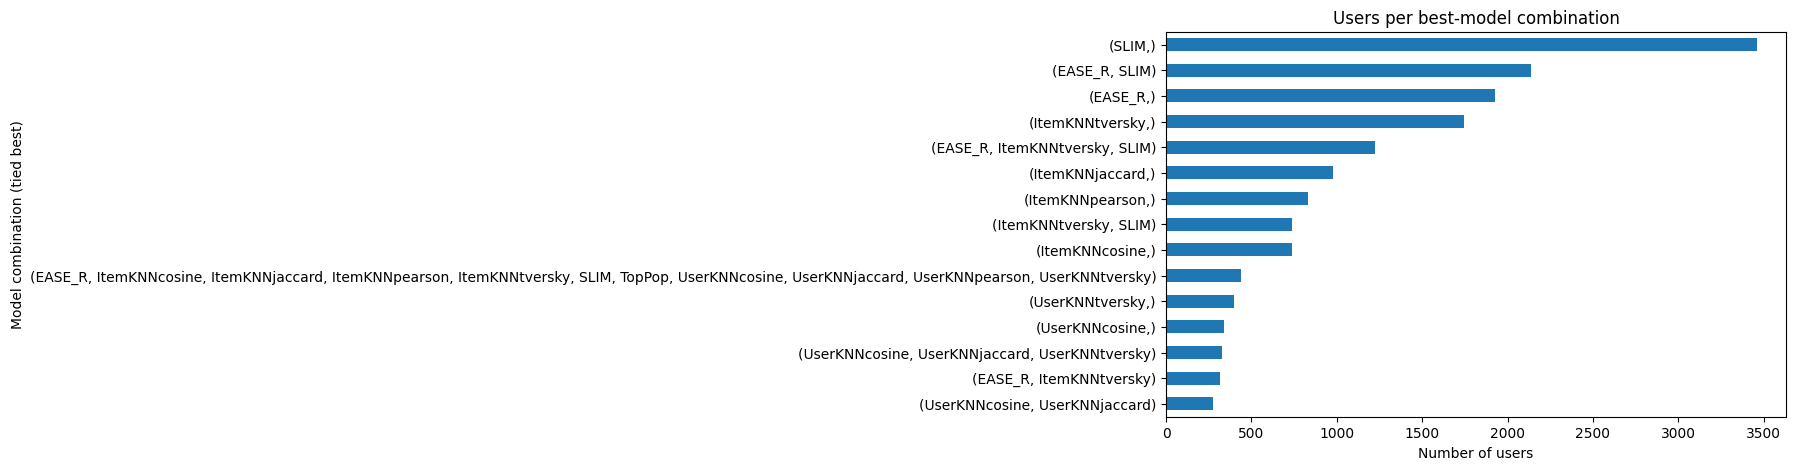

In [17]:
import matplotlib.pyplot as plt

combo_counts.head(15).plot.barh(
    x="best_models_combo", y="n_users", figsize=(8,5), legend=False
)
plt.xlabel("Number of users")
plt.ylabel("Model combination (tied best)")
plt.title("Users per best-model combination")
plt.gca().invert_yaxis()
plt.show()


In [24]:
class MappedModelsRecommender:
    def __init__(self, base_models, user_mapping):
        self.base_models = base_models
        self.user_mapping = user_mapping  # dict mapping original user IDs to model names

    def recommend(self, user_id, cutoff=20):
        model_name = self.user_mapping.get(user_id, None)
        if model_name and model_name in self.base_models:
            model = self.base_models[model_name]
            return model.recommend(user_id, cutoff=cutoff)
        else:
            print(f"Warning: No model mapped for user {user_id}. Using fallback.")
            # Fallback: use a default model (e.g., TopPop)
            default_model = self.base_models.get('TopPop', None)
            if default_model:
                return default_model.recommend(user_id, cutoff=cutoff)
            else:
                return []  # No recommendation available

In [19]:
# Get the best model for each user
user_best_model_mapping = df_models_performance.idxmax(axis=1).to_dict()

# Create the MappedModelsRecommender with the best model for each user
mapped_recommender = MappedModelsRecommender(models, user_best_model_mapping)

# Evaluate MappedModelsRecommender
mapped_recall = evaluate_recommender(mapped_recommender, at=20)
print(f"Mapped Models Recommender - Recall@20: {mapped_recall:.5f}")

/tmp/ipykernel_355317/917200562.py:2: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  user_best_model_mapping = df_models_performance.idxmax(axis=1).to_dict()


Mapped Models Recommender - Recall@20: 0.34459


### **Retrain models on train+validation set**

In [20]:
print("###   Retrain models on train+validation set   ###")

print("Training SLIM model...")
slim_model = SLIMElasticNetRecommender(URM_train+URM_validation)
slim_model.fit(
    l1_ratio=0.6257826858334088,
    alpha=0.000818987106299432,
    topK=646,
    positive_only=False
)
models['SLIM'] = slim_model

print("Training EASE_R model...")
ease_r_model = EASE_R_Recommender(URM_train+URM_validation)
ease_r_model.fit(
    topK=850,
    l2_norm=400.12671834453766,
    normalize_matrix=False
)
models['EASE_R'] = ease_r_model

print("Training TopPop model...")
# Train TopPop model
toppop_model = TopPop(URM_train+URM_validation)
toppop_model.fit()
models['TopPop'] = toppop_model

print("Training UserKNN models...")
params = {
    "cosine": {"topK": 347, "shrink": 3, "normalize": True, "feature_weighting": "TF-IDF"},
    "pearson": {"topK": 2850, "shrink": 935, "normalize": True, "feature_weighting": "TF-IDF"},
    "jaccard": {"topK": 301, "shrink": 0, "normalize": True, "feature_weighting": "none"},
    "tversky": {"topK": 401, "shrink": 5, "normalize": False, "feature_weighting": "TF-IDF", "alpha": 0.2184775930703794, "beta": 0.5934354684918872}
}

for sim in SIMILIARITIES:
    # Train UserKNN model with best parameters
    print(f"  {sim}...")
    userknn_model = UserKNNCFRecommender(URM_train+URM_validation)

    if sim == "tversky":
        userknn_model.fit(
            similarity=sim,
            topK=params[sim]["topK"],
            shrink=params[sim]["shrink"],
            normalize=params[sim]["normalize"],
            feature_weighting=params[sim]["feature_weighting"],
            tversky_alpha=params[sim]["alpha"],
            tversky_beta=params[sim]["beta"]
        )
    else:
        userknn_model.fit(
            similarity=sim,
            topK=params[sim]["topK"],
            shrink=params[sim]["shrink"],
            normalize=params[sim]["normalize"],
            feature_weighting=params[sim]["feature_weighting"]
        )

    # Add UserKNN model to models dictionary
    models['UserKNN'+sim] = userknn_model


print("Training ItemKNN models...")
params = {
    "cosine": {"topK": 79, "shrink": 431, "normalize": True, "feature_weighting": "TF-IDF"},
    "pearson": {"topK": 11, "shrink": 3, "normalize": True, "feature_weighting": "TF-IDF"},
    "jaccard": {"topK": 1101, "shrink": 0, "normalize": True, "feature_weighting": "BM25"},
    "tversky": {"topK": 6, "shrink": 106, "normalize": True, "feature_weighting": "TF-IDF", "tversky_alpha": 0.10252983277640502, "tversky_beta": 0.9684276681445425}
}

for sim in SIMILIARITIES:
    print(f"  {sim}...")
    itemknn_model = ItemKNNCFRecommender(URM_train+URM_validation)
    
    if sim == "tversky":
        itemknn_model.fit(
            similarity=sim,
            topK=params[sim]["topK"],
            shrink=params[sim]["shrink"],
            normalize=params[sim]["normalize"],
            feature_weighting=params[sim]["feature_weighting"],
            tversky_alpha=params[sim]["tversky_alpha"],
            tversky_beta=params[sim]["tversky_beta"]
        )
    else:
        itemknn_model.fit(
            similarity=sim,
            topK=params[sim]["topK"],
            shrink=params[sim]["shrink"],
            normalize=params[sim]["normalize"],
            feature_weighting=params[sim]["feature_weighting"]
        )

    # Add ItemKNN model to models dictionary
    models['ItemKNN'+sim] = itemknn_model

###   Retrain models on train+validation set   ###
Training SLIM model...
SLIMElasticNetRecommender: Processed 6509 (93.4%) in 5.00 min. Items per second: 21.69
SLIMElasticNetRecommender: Processed 6969 (100.0%) in 5.34 min. Items per second: 21.74
Training EASE_R model...
EASE_R_Recommender: Fitting model... 
EASE_R_Recommender: Fitting model... done in 7.48 sec
Training TopPop model...
Training UserKNN models...
  cosine...
Similarity column 27095 (100.0%), 1441.76 column/sec. Elapsed time 18.79 sec
  pearson...
Similarity column 27095 (100.0%), 1468.80 column/sec. Elapsed time 18.45 sec
  jaccard...
Similarity column 27095 (100.0%), 1456.90 column/sec. Elapsed time 18.60 sec
  tversky...
Similarity column 27095 (100.0%), 1434.00 column/sec. Elapsed time 18.89 sec
Training ItemKNN models...
  cosine...
Similarity column 6969 (100.0%), 3538.92 column/sec. Elapsed time 1.97 sec
  pearson...
Similarity column 6969 (100.0%), 3521.21 column/sec. Elapsed time 1.98 sec
  jaccard...
Similari

### **Generate submissions**

In [25]:
import pandas as pd

# Create the MappedModelsRecommender with the best model for each user
mapped_recommender = MappedModelsRecommender(models, user_best_model_mapping)

# Generate recommendations for the test set
user_ids_test = pd.read_csv(paths.CHALLENGE_USER_IDS_TEST)
ids = user_ids_test["user_id"].values

os.makedirs(paths.SUBMISSIONS, exist_ok=True)
with open(os.path.join(paths.SUBMISSIONS, "hybridModelToUser.csv"), "w") as f:
    f.write("user_id,item_list\n")
    for user_id in ids:
        recommendations = mapped_recommender.recommend(user_id, cutoff=20)
        f.write(f"{user_id},{' '.join([str(item) for item in recommendations])}\n")